In [25]:
import pandas as pd

# Display 200 rows
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', None)

In [26]:
# Read metadata.csv
metadata = pd.read_csv('metadata.csv')

# Delete the .arff from the name
metadata['name'] = metadata['name'].str.replace('.arff', '')

metadata.head()

,name,subfolder,nInstances,nAttributes,nClasses,discAtts,numAtts
0,Abalone,AnDE,4177,9,3,1,8
1,Adult,AnDE,48842,15,2,9,6
2,Annealing,AnDE,898,39,6,33,6
3,Auto_Imports,AnDE,205,26,7,11,15
4,Balance_Scale,AnDE,625,5,3,1,4


In [27]:
# Order by subfolder, nInstances
metadata = metadata.sort_values(by=['subfolder', 'nInstances']).reset_index(drop=True)
metadata

,name,subfolder,nInstances,nAttributes,nClasses,discAtts,numAtts
0,Labor_negotiations,AnDE,57,17,2,9,8
1,Zoo,AnDE,101,17,7,16,1
2,Echocardiogram,AnDE,131,11,2,2,9
3,Lymphography,AnDE,148,19,4,16,3
4,Iris_Classification,AnDE,150,5,3,1,4
...,...,...,...,...,...,...,...
236,Bank-marketing,Nuevas,45211,17,2,10,7
237,Electricity,Nuevas,45312,9,2,2,7
238,KDD_Cup_09_Upselling,Nuevas,50000,231,2,39,192
239,Higgs,Nuevas,98050,29,2,1,28


In [28]:
# Order by numAtts
metadata = metadata.sort_values(by=['numAtts']).reset_index(drop=True)
metadata[metadata['nInstances'] > 1000]

,name,subfolder,nInstances,nAttributes,nClasses,discAtts,numAtts
0,Amazon_Employee_Access,Discretas,32769,10,2,10,0
1,King-rook-vs-king-pawn,Discretas,3196,37,2,37,0
2,Phising_Websites,Discretas,11055,31,2,31,0
3,Splice-junction_Gene_Sequences,Discretas,3190,61,3,61,0
4,Nursey,Discretas,12960,9,5,9,0
5,King-rook-vs-King,Discretas,28056,7,18,7,0
7,Car_Evaluation,Discretas,1728,7,4,7,0
8,Connect-4_Opening,Discretas,67557,43,3,43,0
9,Flare,Discretas,1066,12,6,12,0
13,Mushrooms,Discretas,8124,23,2,23,0


In [29]:
# Get BBDDs with more than 500 instances
big = metadata[metadata['nInstances'] > 100].sort_values(by=['nInstances'])
big

,name,subfolder,nInstances,nAttributes,nClasses,discAtts,numAtts
182,Breast_GSE59246,Microarray/CuMiDA,101,36623,2,1,36622
20,Zoo,AnDE,101,17,7,16,1
204,Leukemia_GSE63270,Microarray/CuMiDA,101,54676,2,1,54675
128,Prostate_GE,Microarray,102,5967,2,1,5966
137,Prostate,Microarray,102,12601,2,1,12600
212,Throat_GSE42743,Microarray/CuMiDA,103,54676,2,1,54675
148,Colorectal_GSE44861,Microarray/CuMiDA,105,22278,2,1,22277
17,Promoter_Gene_Sequences,Discretas,106,58,4,58,0
134,CLL-SUB-111,Microarray,111,11341,3,1,11340
222,Lung_GSE19804,Microarray/CuMiDA,114,54676,2,1,54675


In [30]:
# Get the names as list, ordered by nInstances
big_names = big.sort_values(by=['nInstances'])['name'].tolist()
big_names

['Breast_GSE59246',
 'Zoo',
 'Leukemia_GSE63270',
 'Prostate_GE',
 'Prostate',
 'Throat_GSE42743',
 'Colorectal_GSE44861',
 'Promoter_Gene_Sequences',
 'CLL-SUB-111',
 'Lung_GSE19804',
 'Prostate_GSE6919_U95C',
 'Breast_GSE26304',
 'Breast_GSE42568',
 'Prostate_GSE6919_U95B',
 'Prostate_GSE6919_U95Av2',
 'Brain_GSE50161',
 'Echocardiogram',
 'Breast_GSE22820',
 'GSE111175',
 'Renal_GSE53757',
 'GSE25507',
 'Colorectal_GSE21510',
 'GSE42133',
 'Lymphography',
 'Iris_Classification',
 'Teaching_Assistant_Evaluation',
 'Breast_GSE45827',
 'Hepatitis',
 'GSE40419',
 'Liver_GSE76427',
 'TOX-171',
 '11_Tumors',
 'Wine_Recognition',
 'GLA-BRA-180',
 'SMK',
 'Colorectal_GSE44076',
 'Lung',
 'Auto_Imports',
 'Sonar_Classification',
 'Glass_Identification',
 'New-Thyroid',
 'GSE123302',
 'Audiology',
 'Ovarian',
 'Leukemia_GSE28497',
 'Breast_GSE70947',
 'Hungarian',
 'Heart_Disease_(Cleverland)',
 'Habermans_Survival',
 'Primary_Tumor',
 'Live_Disorders_(Bupa)',
 'Ionosphere',
 'Liver_GSE14520_

In [31]:
# Get a different list for each subfolder (AnDE, NB y Nuevas)
big.groupby('subfolder')['name'].apply(lambda x: ' '.join(['"' + item + '"' for item in x]))

subfolder
AnDE                      "Zoo" "Echocardiogram" "Lymphography" "Iris_Classification" "Teaching_Assistant_Evaluation" "Hepatitis" "Wine_Recognition" "Auto_Imports" "Sonar_Classification" "Glass_Identification" "New-Thyroid" "Hungarian" "Heart_Disease_(Cleverland)" "Habermans_Survival" "Live_Disorders_(Bupa)" "Ionosphere" "Dermatology" "Horse_colic" "LED" "Cylinder_Bands" "Synthetic_control_(Syncon)" "Balance_Scale" "Credit_Screening" "Breast_Cancer_(Wisconsin)" "Pima_Indians_Diabetes" "Vehicle" "Annealing" "Vowel" "German" "Contraceptive_Metod_Choice" "Segment" "Hypothyroid(Garavan)" "Sick-euthyroid" "Abalone" "SPAM_E-mail" "Waveform-5000" "Nettalk_(Phoneme)" "Page_Blocks" "Optical_Digits" "Volcanoes" "Pen_Digits" "MAGIC_Gamma_Telescope" "Letter_Recognition" "Adult" "Statlog_(Shuttle)" "Census-Income_(KDD)" "Covertype"
Big                                                                                                                                                            

# Discretas

In [32]:
# BBDDs discretas
discretas = metadata[metadata['subfolder'] == 'Discretas']
discretas = discretas.sort_values(by=['nInstances'])

# Solo más de 400 instancias
discretas = discretas[discretas['nInstances'] > 400]

# Borrar subfolder, discAtts, numAtts
discretas = discretas.drop(columns=['subfolder', 'discAtts', 'numAtts'])

# Restar 1 a nAttributes
discretas['nAttributes'] = discretas['nAttributes'] - 1

# to Latex
print(discretas.to_latex(index=False))

\begin{tabular}{lrrr}
\toprule
name & nInstances & nAttributes & nClasses \\
\midrule
House_Votes_84 & 435 & 16 & 2 \\
Soybean & 683 & 35 & 19 \\
Tic-Tac-Toe & 958 & 9 & 2 \\
Flare & 1066 & 11 & 6 \\
Car_Evaluation & 1728 & 6 & 4 \\
Splice-junction_Gene_Sequences & 3190 & 60 & 3 \\
King-rook-vs-king-pawn & 3196 & 36 & 2 \\
Mushrooms & 8124 & 22 & 2 \\
Phising_Websites & 11055 & 30 & 2 \\
Nursey & 12960 & 8 & 5 \\
King-rook-vs-King & 28056 & 6 & 18 \\
Amazon_Employee_Access & 32769 & 9 & 2 \\
Connect-4_Opening & 67557 & 42 & 3 \\
\bottomrule
\end{tabular}



## BBDDs no big

In [33]:
# bbdds no big
metadata[metadata['nInstances'] < 10000]['name'].tolist()

['King-rook-vs-king-pawn',
 'Splice-junction_Gene_Sequences',
 'Contact-lenses',
 'Car_Evaluation',
 'Flare',
 'Tic-Tac-Toe',
 'Soybean',
 'House_Votes_84',
 'Mushrooms',
 'Audiology',
 'Lung_Cancer',
 'Primary_Tumor',
 'Promoter_Gene_Sequences',
 'Postoperative_Patient',
 'Dermatology',
 'Zoo',
 'Habermans_Survival',
 'Contraceptive_Metod_Choice',
 'Lymphography',
 'Teaching_Assistant_Evaluation',
 'Volcanoes',
 'Iris_Classification',
 'Banknote_Authentication',
 'Blood_Transfusion',
 'Balance_Scale',
 'Nettalk_(Phoneme)',
 'New-Thyroid',
 'Annealing',
 'Credit_Screening',
 'Live_Disorders_(Bupa)',
 'Heart_Disease_(Cleverland)',
 'Hungarian',
 'Hepatitis',
 'LED',
 'Thyroid',
 'German',
 'Yeast',
 'Labor_negotiations',
 'Abalone',
 'Pima_Indians_Diabetes',
 'Breast_Cancer_(Wisconsin)',
 'Glass_Identification',
 'Echocardiogram',
 'Page_Blocks',
 'Vowel',
 'Marketing',
 'Wine_Recognition',
 'Japanese_Vowels',
 'Auto_Imports',
 'Vehicle',
 'Cylinder_Bands',
 'Segment',
 'Hypothyroid(Gar

In [34]:
# Get a different list for each subfolder (AnDE, NB y Nuevas)
metadata[metadata['nInstances'] < 10000].groupby('subfolder')['name'].apply(lambda x: ' '.join(['"' + item + '"' for item in x]))

subfolder
AnDE                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             "Dermatology" "Zoo" "Habermans_Survival" "Contraceptive_Metod_Choice" "Lymphography" "Teaching_Assistant_Evaluation" "Volcanoes" "Iris_Classification" "Balance_Scale" "Nettalk_(Phoneme)" "New-Thyroid" "Annealing" "Credit_Screening" "Live_Disorders_(Bupa)" "Heart_Disease_(Cleverland)" 

In [35]:
# Read metadata.csv
metadata = pd.read_csv('metadata.csv')

# Delete the .arff from the name
metadata['name'] = metadata['name'].str.replace('.arff', '')

metadata.head()

,name,subfolder,nInstances,nAttributes,nClasses,discAtts,numAtts
0,Abalone,AnDE,4177,9,3,1,8
1,Adult,AnDE,48842,15,2,9,6
2,Annealing,AnDE,898,39,6,33,6
3,Auto_Imports,AnDE,205,26,7,11,15
4,Balance_Scale,AnDE,625,5,3,1,4


KeyError: 'nItersNBw5'

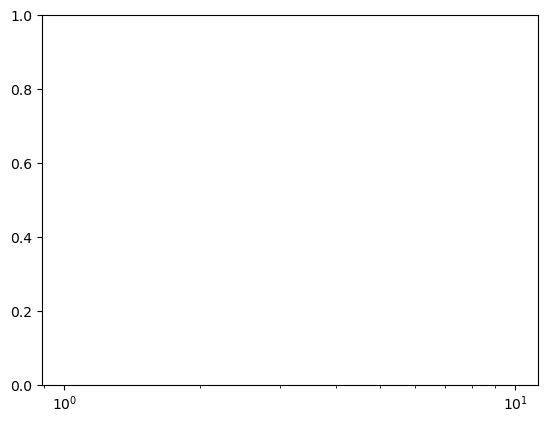

In [36]:
# plot nItersNBw5 vs nInstances
metadata.plot.scatter(x='nInstances', y='nItersNBw5', logx=True)

<Axes: xlabel='nAttributes', ylabel='nItersNBw5'>

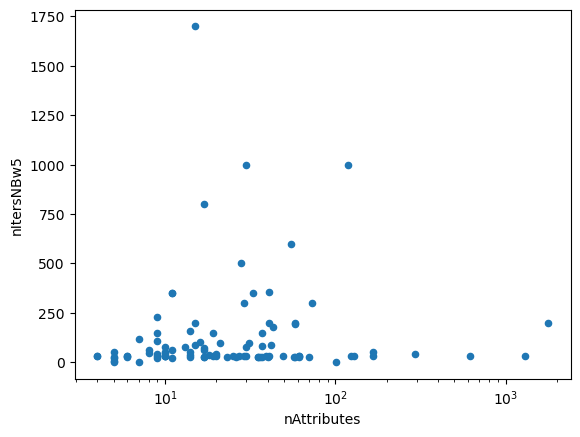

In [ ]:
metadata.plot.scatter(x='nAttributes', y='nItersNBw5', logx=True)

<Axes: xlabel='nClasses', ylabel='nItersNBw5'>

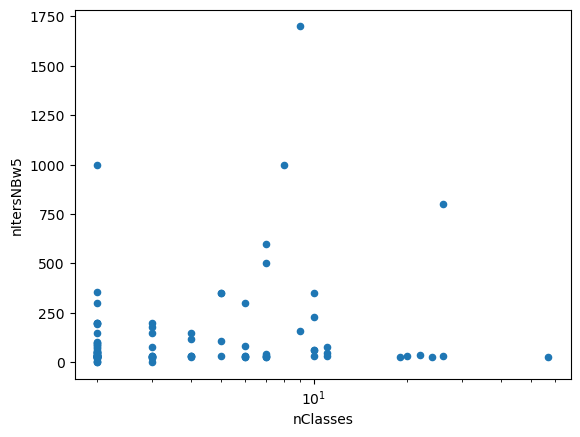

In [ ]:
metadata.plot.scatter(x='nClasses', y='nItersNBw5', logx=True)

<Axes: xlabel='nAttributesClasses', ylabel='nItersNBw5'>

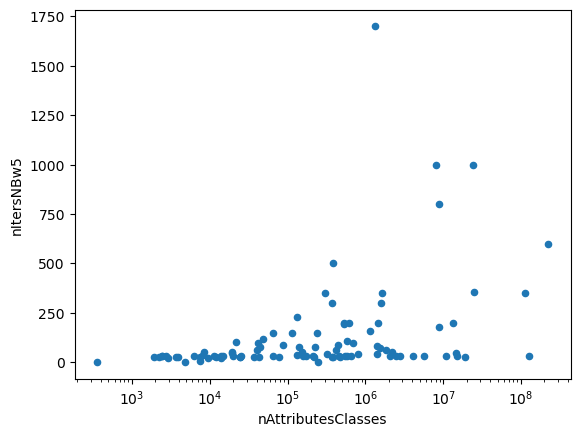

In [ ]:
# new column with the multiplication of nAttributes and nClasses and nInstances
metadata['nAttributesClasses'] = metadata['nAttributes'] * metadata['nClasses'] * metadata['nInstances']
metadata.plot.scatter(x='nAttributesClasses', y='nItersNBw5', logx=True)